In [1]:
%load_ext autoreload
%autoreload 2

In [2]:


from Nozzle_2D_checkpoint4_2 import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



In [3]:
SUPERCOARSE = Nozzle("inputs/Medium_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000

# RUN MEDIUM SIMULATION
self.set_arrays()
#self.set_geometry()
self.set_curved_geometry()
#self.load_grid("Meshes/NACA64A006.coarse.53x27.grd")
#self.set_nozzle_BC()
#self.set_nozzle_BC()
#self.set_ramp_BC()
#self.load_grid("Meshes/Inlet.53x17.grd")
#self.load_grid("Meshes/Inlet.417x129.grd") # boundary conditions increments of 20,40,80,160
self.set_normals()
self.compute_all_areas()
self.set_initial_foil_conditions()
#self.set_top_boundary_conditions()
self.is_foil = False
#R1 = self.iteration_step()
#self.set_boundary_conditions()


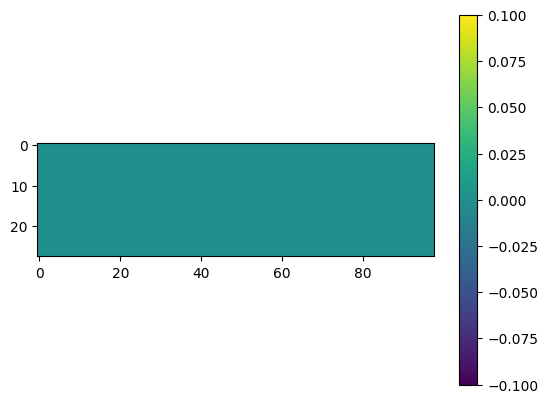

In [4]:
plt.imshow(self.V[2])
plt.colorbar()

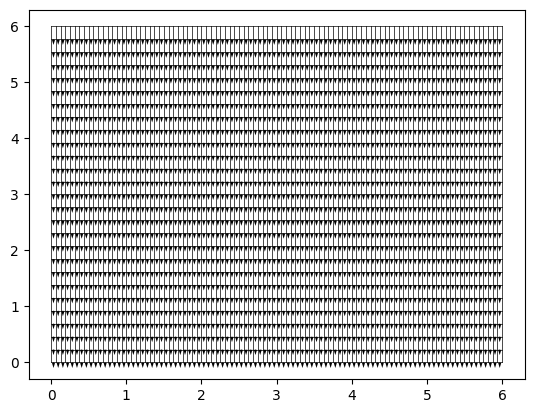

In [5]:
Test = self
# Plot horizontal lines (along y)
for i in range(Test.NI):
    plt.plot(Test.x[i, :], Test.y[i, :], color='black', linewidth=0.5)

# Plot vertical lines (along x)
for j in range(Test.NJ):
    plt.plot(Test.x[:, j], Test.y[:, j], color='black', linewidth=0.5)

nx,ny  = self.get_normal_directions("up")
#plt.quiver(self.downward_S[0,:,:],self.downward_S[1,:,:],-self.downward_S[2,:,:],-self.downward_S[3,:,:])
#plt.quiver(self.upward_normal[0,-1,:],self.upward_normal[1,-1,:],nx[-1,:],ny[-1,:])
plt.quiver(self.downward_normal[0,:,:],self.downward_normal[1,:,:],self.downward_normal[2,:,:],self.downward_normal[3,:,:])
#plt.quiver(self.rightward_normal[0,:,0],self.rightward_normal[1,:,0],self.rightward_normal[2,:,0],self.rightward_normal[3,:,0])

In [6]:
print(range(16+1,self.NJ-16+1))

range(17, 82)


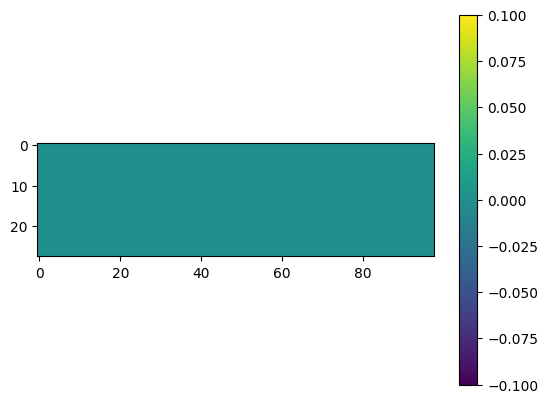

In [7]:
#self.set_top_boundary_conditions()
#self.set_normal_bcs()
self.set_foil_inflow()
R0 = np.linalg.norm(self.iteration_step()[0])
plt.imshow(self.V[2,::-1])
plt.colorbar()

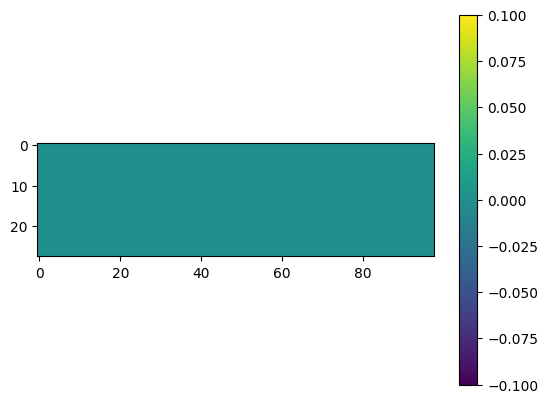

In [8]:
self.set_foil_inflow()
self.CFL = .5
self.iteration_step()
plt.imshow(self.V[2])
plt.colorbar()

In [9]:

vals = np.sin(np.linspace(0, 1, self.V.shape[2]))  # along j-direction
vals = np.tile(vals, (self.V.shape[1], 1))         # repeat along i-direction


In [10]:
self.V[1:3].shape

(2, 28, 98)

In [33]:
self.CFL = .01
for i in range(13000):

    self.set_foil_inflow(boundary_mach=2)
    #self.set_top_boundary_conditions()
    R1 = self.iteration_step()
    #self.set_top_boundary_conditions()
    #self.set_normal_bcs_FOIL()
    self.set_foil_inflow(boundary_mach=2)

    
    #self.set_normal_bcs()
    print(f"Iteration{i}  ",np.linalg.norm(R1[0])/(R0))
plt.imshow(self.V[1,::-1])
plt.colorbar()


Iteration0   1.0531235504348462
Iteration1   1.0463157946963197
Iteration2   1.0395383922228911
Iteration3   1.0327911466781314
Iteration4   1.0260738628148882
Iteration5   1.019386346469815
Iteration6   1.012728404557965
Iteration7   1.0060998450674443
Iteration8   0.9995004770541422
Iteration9   0.992930110636518
Iteration10   0.9863885569904629
Iteration11   0.9798756283442257
Iteration12   0.9733911379734118
Iteration13   0.9669349001960497
Iteration14   0.9605067303677304
Iteration15   0.9541064448768171
Iteration16   0.9477338611397315
Iteration17   0.9413887975963122
Iteration18   0.9350710737052461
Iteration19   0.9287805099395829
Iteration20   0.9225169277823227
Iteration21   0.9162801497220817
Iteration22   0.9100699992488436
Iteration23   0.9038863008497886
Iteration24   0.8977288800052079
Iteration25   0.891597563184501
Iteration26   0.8854921778422639
Iteration27   0.8794125524144609
Iteration28   0.8733585163146893
Iteration29   0.8673298999305363
Iteration30   0.86132653

KeyboardInterrupt: 

In [34]:
#np.save("checkpoint_V2",self.V)
#np.save("checkpoint_U2",self.U)

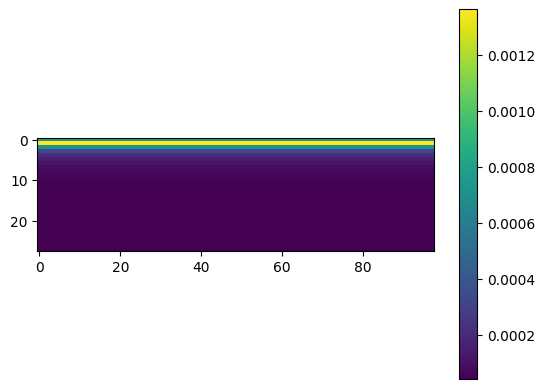

In [35]:
self.set_foil_inflow()
plt.imshow(self.V[0,::-1])
plt.colorbar()

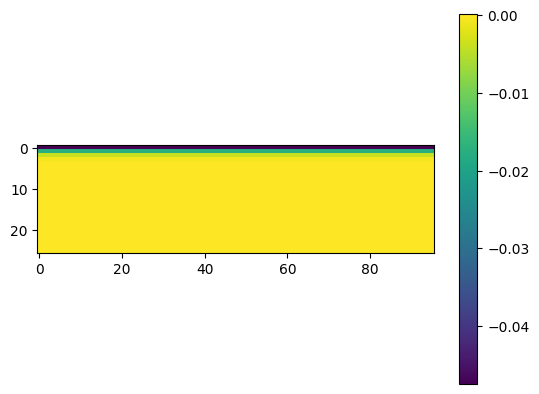

In [36]:
plt.imshow(R1[0,::-1])
plt.colorbar()

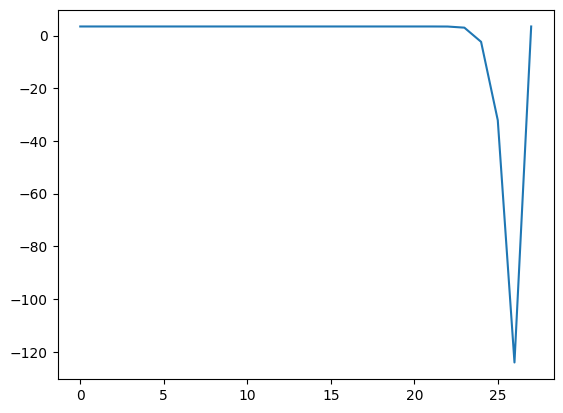

In [37]:
plt.plot(self.V[1,:,2])

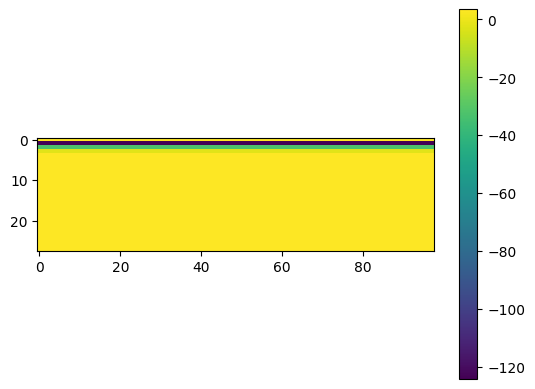

In [38]:
plt.imshow(self.V[1,::-1])
plt.colorbar()

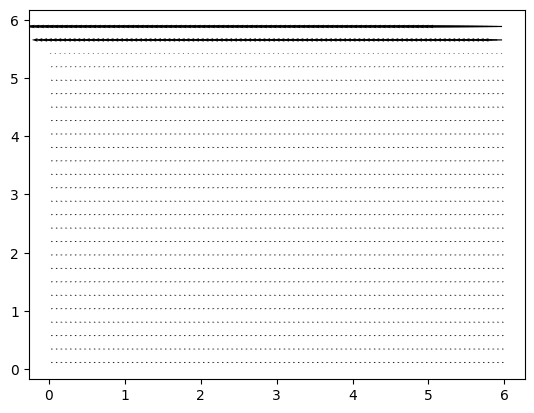

In [39]:
self.plot_primitive("velocity")



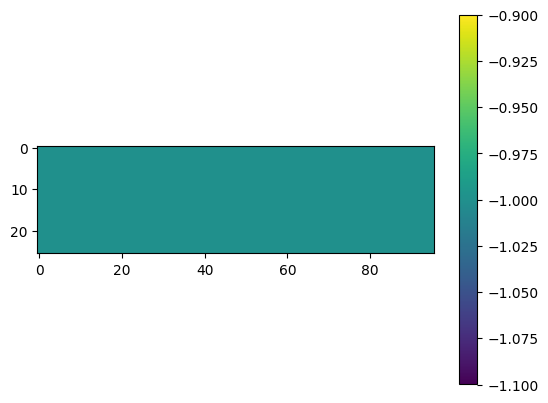

In [40]:

plt.imshow(self.get_normal_directions("down")[1])
plt.colorbar()

In [41]:
self.downward_normal[2,0,0:16] # 0:16 on airfoil, 80:

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

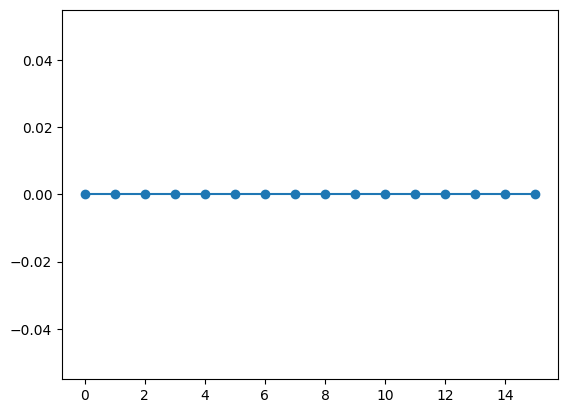

In [42]:
plt.plot(self.downward_normal[2,0,80:],"-o")